In [1]:
from langgraph.graph import StateGraph,START,END #dummynodes
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os
load_dotenv()

True

In [2]:
model=ChatOpenAI()

In [ ]:
class BlogState(TypedDict):
    topic: str
    outline: str
    blog: str
    score: int
    quality_feedback: str

In [22]:
def gen_outline(state:BlogState)->BlogState:
    topic=state["topic"]
    prompt=f"Generate a detailed outline for a blog on the topic: {topic}"
    response=model.invoke(prompt)
    outline=response.content
    state["outline"]=outline
    return state

In [23]:
def gen_blog(state:BlogState)->BlogState:
    outline=state["outline"]
    topic=state["topic"]
    prompt=f"Write a blog post based on the following outline: {outline} for the topic: {topic}"
    response=model.invoke(prompt)
    blog=response.content
    state["blog"]=blog
    return state

In [24]:
def eval_blog(state:BlogState)->BlogState:
    blog=state["blog"]
    outline=state["outline"]
    prompt=f"Based on the following outline: {outline} and the generated blog: {blog}, rate the blog on a scale of 1-10 and provide feedback for improvement."
    response=model.invoke(prompt)
    quality=response.content
    state["quality_feedback"]=quality
    return state

In [25]:
#add nodes to the graph
graph=StateGraph(BlogState)
# graph.add_node(START)
graph.add_node("gen_outline",gen_outline)
graph.add_node("gen_blog",gen_blog)
graph.add_node("eval_blog",eval_blog)
#add edges to the graph
graph.add_edge(START,"gen_outline")
graph.add_edge("gen_outline","gen_blog")
graph.add_edge("gen_blog","eval_blog")
graph.add_edge("eval_blog",END) #final node pe state ko

workflow=graph.compile()

In [26]:
initial_state={"topic": "lukemia"}
output_state=workflow.invoke(initial_state)#graph ko input ke waqt v state pass karna hota hai aur end hone ke bad output v state milta hai 
print(output_state)

{'topic': 'lukemia', 'outline': 'I. Introduction\n    A. Definition of lukemia\n    B. Brief overview of the different types of lukemia\n    C. Importance of early detection and treatment\n    \nII. Causes and risk factors of lukemia\n    A. Genetic factors\n    B. Environmental factors\n    C. Radiation exposure\n    D. Chemical exposure\n    E. Viral infections\n    \nIII. Symptoms of lukemia\n    A. Common symptoms\n    B. Less common symptoms\n    C. Complications of untreated lukemia\n    \nIV. Diagnosis of lukemia\n    A. Blood tests\n    B. Bone marrow biopsy\n    C. Imaging tests\n    D. Genetic testing\n    \nV. Treatment options for lukemia\n    A. Chemotherapy\n    B. Radiation therapy\n    C. Stem cell transplant\n    D. Targeted therapy\n    E. Immunotherapy\n    \nVI. Side effects of lukemia treatment\n    A. Short-term side effects\n    B. Long-term side effects\n    C. How to manage side effects\n    \nVII. Prognosis and survival rates\n    A. Factors affecting prognosi

In [27]:
print(output_state["blog"])

Leukemia is a type of cancer that affects the blood and bone marrow. It is characterized by the rapid production of abnormal white blood cells, which crowd out healthy blood cells and impair the body's ability to fight infection. There are several different types of leukemia, including acute lymphoblastic leukemia (ALL), acute myeloid leukemia (AML), chronic lymphocytic leukemia (CLL), and chronic myeloid leukemia (CML). Each type of leukemia has its own distinct characteristics and treatment options, but they all share the importance of early detection and treatment.

Causes and risk factors of leukemia can include genetic factors, environmental factors (such as exposure to certain chemicals or radiation), and viral infections. It's important for individuals to be aware of these risk factors and to seek medical attention if they experience any symptoms of leukemia.

Symptoms of leukemia may vary depending on the type of leukemia and the stage of the disease, but common symptoms can in

In [28]:
print(output_state["quality_feedback"])

I would rate this blog a 9 out of 10. It provides a comprehensive overview of leukemia, including information on causes, symptoms, diagnosis, treatment options, prognosis, and living with leukemia. The blog is well-organized and covers important topics relevant to individuals affected by leukemia.

To improve the blog, I would suggest adding more statistics or specific examples to support the information provided. Additionally, including personal stories or testimonials from individuals who have been affected by leukemia could make the content more engaging and relatable. Lastly, providing more information on specific support resources or organizations for leukemia patients and caregivers could be helpful for readers looking for additional assistance. Overall, this blog is informative and well-written, but could benefit from some additional details and personal anecdotes.


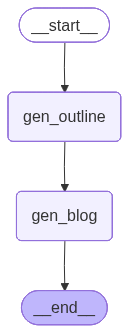

In [14]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [16]:
print(output_state["outline"])

I. Introduction
    A. Definition of leukemia
    B. Importance of raising awareness about leukemia
    C. Preview of topics to be discussed in the blog
    
II. Background information on leukemia
    A. What is leukemia?
    B. Types of leukemia (acute vs. chronic, lymphocytic vs. myeloid)
    C. Causes and risk factors for developing leukemia
    D. Statistics on leukemia prevalence and mortality rates
    
III. Symptoms and diagnosis of leukemia
    A. Common symptoms of leukemia (fatigue, frequent infections, easy bruising)
    B. Diagnostic tests for leukemia (blood tests, bone marrow biopsy)
    C. Importance of early detection and timely diagnosis
    
IV. Treatment options for leukemia
    A. Chemotherapy
    B. Radiation therapy
    C. Stem cell transplant
    D. Targeted therapy
    E. Immunotherapy
    F. Clinical trials for new leukemia treatments
    
V. Coping with leukemia
    A. Emotional impact of a leukemia diagnosis
    B. Support and resources for leukemia patients 